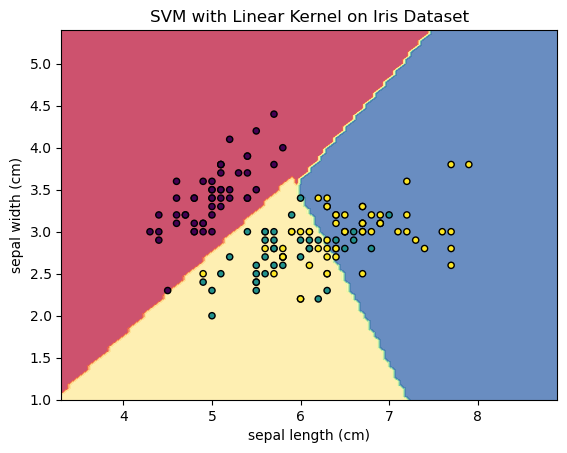

In [1]:
# QUESTION 1
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.svm import SVC


iris = load_iris()
X = iris.data[:, :2] 
y = iris.target
svm = SVC(kernel="linear", C=1.0)
svm.fit(X, y)
DecisionBoundaryDisplay.from_estimator(
    svm,
    X,
    response_method="predict",
    cmap=plt.cm.Spectral,
    alpha=0.8,
    xlabel=iris.feature_names[0],
    ylabel=iris.feature_names[1],
)
plt.scatter(X[:, 0], X[:, 1],
            c=y,
            s=20, edgecolors="k")
plt.title("SVM with Linear Kernel on Iris Dataset")
plt.show()


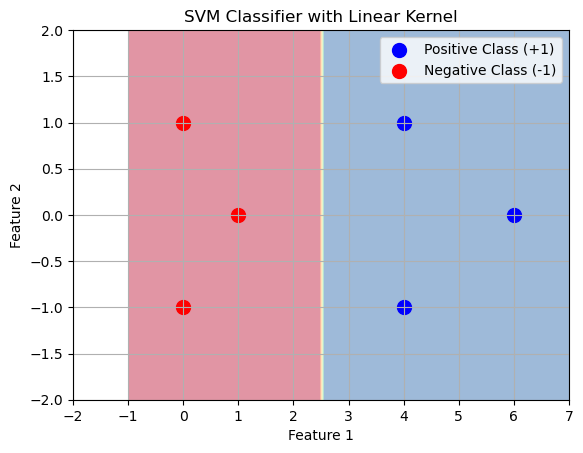

In [2]:
#QUESTION 2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

X = np.array([[4, 1], [4, -1], [6, 0],  
              [1, 0], [0, 1], [0, -1]])

y = np.array([1, 1, 1, -1, -1, -1]) 

svm = SVC(kernel='linear')

svm.fit(X, y)
DecisionBoundaryDisplay.from_estimator(
    svm,
    X,
    response_method='predict',
    cmap=plt.cm.Spectral,
    alpha=0.5,
    xlabel='Feature 1',
    ylabel='Feature 2'
)

plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Positive Class (+1)', s=100)
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], color='red', label='Negative Class (-1)', s=100)
plt.title('SVM Classifier with Linear Kernel')
plt.legend()
plt.xlim(-2, 7)
plt.ylim(-2, 2)
plt.grid()
plt.show()


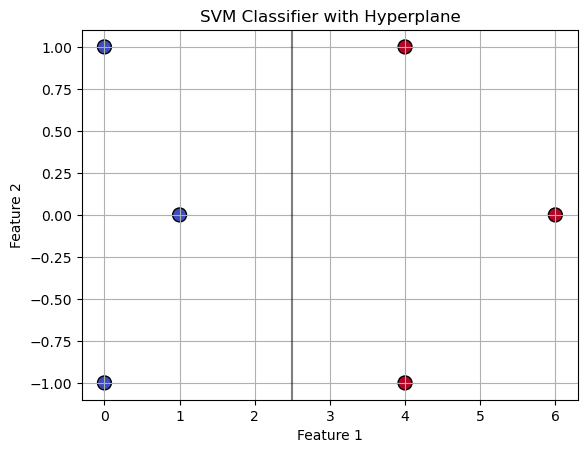

In [16]:
#QUESTION 3
import numpy as np
import matplotlib.pyplot as plt

def svm_fit(X, y):
    y = np.where(y == 0, -1, 1) 
    n_samples, n_features = X.shape
    X_bias = np.hstack((X, np.ones((n_samples, 1))))  
    w = np.zeros(n_features + 1)
    learning_rate = 0.01
    lambda_param = 0.01  
    epochs = 1000
    for epoch in range(epochs):
        for i in range(n_samples):
            if y[i] * np.dot(X_bias[i], w) < 1:
                w = w * (1 - learning_rate * lambda_param) + learning_rate * y[i] * X_bias[i]
            else:  
                w = w * (1 - learning_rate * lambda_param)
    return w

def plot_svm_classifier(X, y, w):  
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=100, edgecolors='k')
    xlim = plt.xlim()
    ylim = plt.ylim() 
    xx, yy = np.meshgrid(np.linspace(xlim[0], xlim[1], 50),
                         np.linspace(ylim[0], ylim[1], 50))   
    Z = (-(w[0] * xx + w[2]) / w[1])  
    plt.contour(xx, yy, Z, colors='k', levels=[0], alpha=0.5)
    plt.title("SVM Classifier with Hyperplane")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid()
    plt.show()

def main():
    X = np.array([[4, 1], [4, -1], [6, 0],  
                  [1, 0], [0, 1], [0, -1]])  
    y = np.array([1, 1, 1, 0, 0, 0])  
    w = svm_fit(X, y)
    plot_svm_classifier(X, y, w)
main()

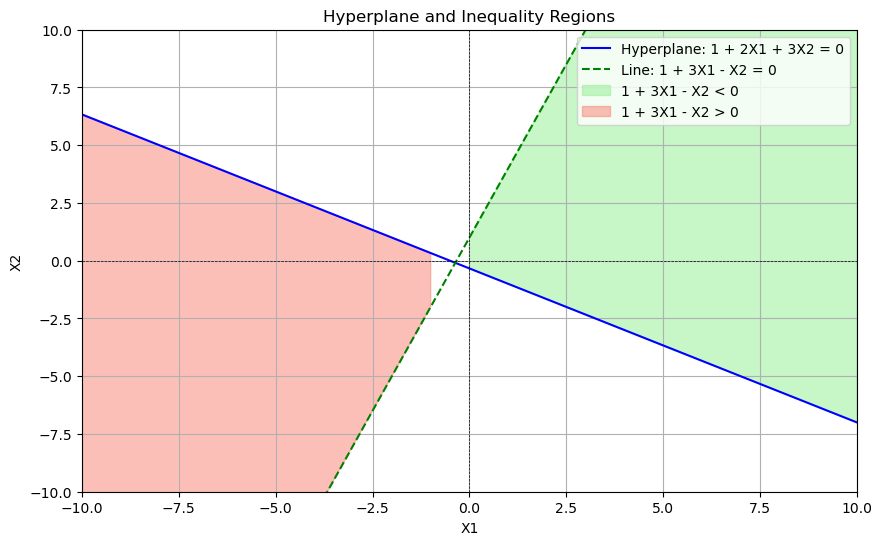

In [7]:
#QUESTION 4
import numpy as np
import matplotlib.pyplot as plt

def plot_hyperplanes():
    x1 = np.arange(-10, 11, 1)
    x2_hyperplane = (-1 - 2 * x1) / 3
    x2_inequality = 1 + 3 * x1
    plt.figure(figsize=(10, 6))
    plt.plot(x1, x2_hyperplane, label='Hyperplane: 1 + 2X1 + 3X2 = 0', color='blue')
    plt.plot(x1, x2_inequality, label='Line: 1 + 3X1 - X2 = 0', color='green', linestyle='--')
    plt.fill_between(x1, x2_hyperplane, x2_inequality, where=(x2_hyperplane < x2_inequality), 
                     color='lightgreen', alpha=0.5, label='1 + 3X1 - X2 < 0')
    plt.fill_between(x1, x2_hyperplane, x2_inequality, where=(x2_hyperplane > x2_inequality), 
                     color='salmon', alpha=0.5, label='1 + 3X1 - X2 > 0')

    plt.title('Hyperplane and Inequality Regions')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.grid()
    plt.legend()
    plt.show()
plot_hyperplanes()


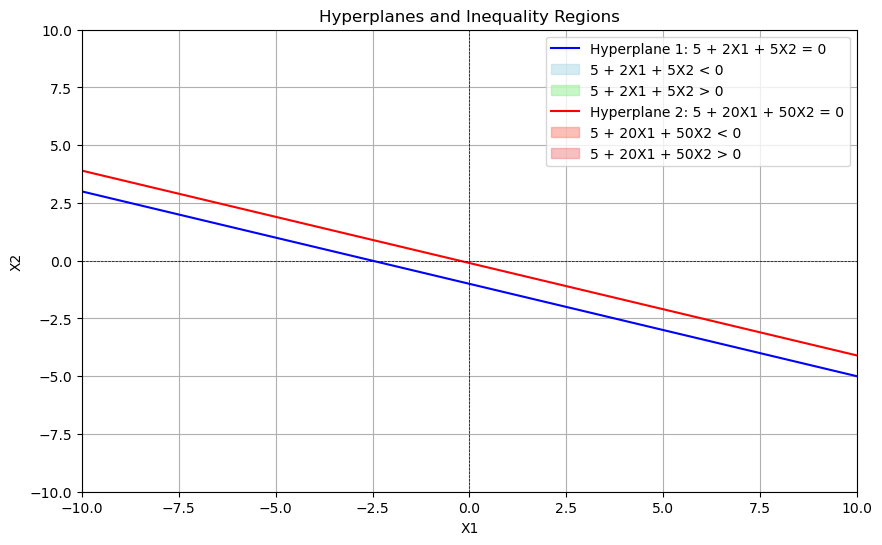

In [5]:
#QUESTION 5
import numpy as np
import matplotlib.pyplot as plt

def plot_hyperplanes():
    x1 = np.linspace(-10, 10, 400)
    x2_hyperplane1 = (-5 - 2 * x1) / 5
    x2_hyperplane2 = (-5 - 20 * x1) / 50
    plt.figure(figsize=(10, 6))
    plt.plot(x1, x2_hyperplane1, label='Hyperplane 1: 5 + 2X1 + 5X2 = 0', color='blue')
    plt.fill_between(x1, x2_hyperplane1, -10, where=(x2_hyperplane1 < -10), 
                     color='lightblue', alpha=0.5, label='5 + 2X1 + 5X2 < 0')
    plt.fill_between(x1, x2_hyperplane1, 10, where=(x2_hyperplane1 > 10), 
                     color='lightgreen', alpha=0.5, label='5 + 2X1 + 5X2 > 0')
    plt.plot(x1, x2_hyperplane2, label='Hyperplane 2: 5 + 20X1 + 50X2 = 0', color='red')
    plt.fill_between(x1, x2_hyperplane2, -10, where=(x2_hyperplane2 < -10), 
                     color='salmon', alpha=0.5, label='5 + 20X1 + 50X2 < 0')
    plt.fill_between(x1, x2_hyperplane2, 10, where=(x2_hyperplane2 > 10), 
                     color='lightcoral', alpha=0.5, label='5 + 20X1 + 50X2 > 0')
    plt.title('Hyperplanes and Inequality Regions')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.xlim(-10, 10)
    plt.ylim(-10, 10)
    plt.axhline(0, color='black', lw=0.5, ls='--')
    plt.axvline(0, color='black', lw=0.5, ls='--')
    plt.grid()
    plt.legend()
    plt.show()

plot_hyperplanes()


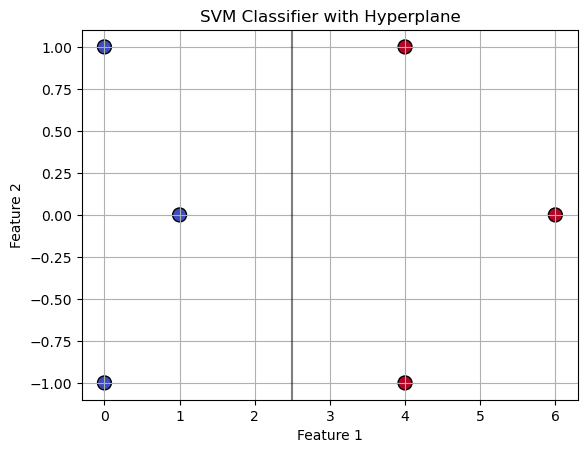